In [1]:
# Run this cell to set up packages for lecture.
from lec15_imports import *

# Lecture 15 – Confidence Intervals, Center, and Spread

## DSC 10, Winter 2026

### Agenda

- Interpreting confidence intervals.
- Pitfalls of bootstrapping.
- Center and spread.
    - Recap: Mean and median.
    - Standard deviation.

## Interpreting confidence intervals

### Recap: City of San Diego employee salaries

Let's rerun our code from last time to compute a 95% confidence interval for the median salary of all San Diego city employees, based on a sample of 500 people.

**Step 1**: Collect a single sample of size 500 from the population.

In [2]:
population = bpd.read_csv('data/2023_salaries.csv').get(['TotalWages'])
population_median = population.get('TotalWages').median()
population_median # Can't see this in real life!

np.float64(80492.0)

In [3]:
np.random.seed(38) # Magic to ensure that we get the same results every time this code is run.
my_sample = population.sample(500)
sample_median = my_sample.get('TotalWages').median()
sample_median

np.float64(82508.0)

**Step 2**: Bootstrap! That is, resample from the sample a large number of times, and each time, compute the median of the resample. This will generate an empirical distribution of the sample median.

In [4]:
np.random.seed(38) # Magic to ensure that we get the same results every time this code is run.

# Bootstrap the sample to get more sample medians.
n_resamples = 5000
boot_medians = np.array([])

for i in np.arange(n_resamples):
    resample = my_sample.sample(500, replace=True)
    median = resample.get('TotalWages').median()
    boot_medians = np.append(boot_medians, median)
    
boot_medians

array([85751. , 76009. , 83106. , ..., 82760. , 83470.5, 82711. ],
      shape=(5000,))

**Step 3**: Take the middle 95% of the empirical distribution of sample medians (i.e. `boot_medians`). This creates our 95% confidence interval.

In [5]:
left = np.percentile(boot_medians, 2.5)
right = np.percentile(boot_medians, 97.5)

# Therefore, our interval is:
[left, right]

[np.float64(70671.5), np.float64(86405.0)]

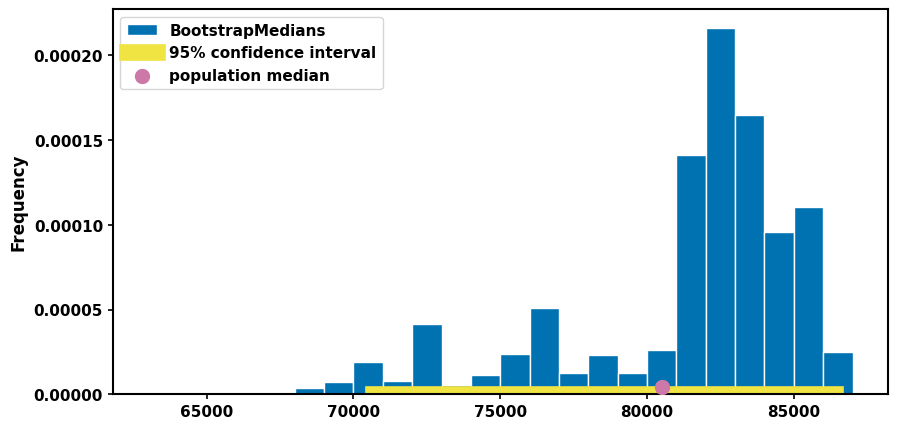

In [6]:
bpd.DataFrame().assign(BootstrapMedians=boot_medians).plot(kind='hist', density=True, bins=np.arange(63000, 88000, 1000), ec='w', figsize=(10, 5))
plt.plot([left, right], [0, 0], color=gold, linewidth=12, label='95% confidence interval');
plt.scatter(population_median, 0.000004, color=pink, s=100, label='population median').set_zorder(3)
plt.legend();

### Confidence intervals describe a guess for the value of an unknown parameter

Now, instead of saying

> We think the population median is close to our sample median, \\$82,508.

We can say:

> A 95% confidence interval for the population median is \\$70,671.50 to \\$86,405.

**Today, we'll address**: What does 95% confidence mean? What are we confident about? Is this technique always "good"?

### Interpreting confidence intervals

- We created a confidence interval that contained 95% of our bootstrapped sample medians.
- We're pretty confident that it contains the true population median, too
- How confident should we be about this? **What does a 95% confidence level mean?**

### Capturing the true value

- Consider the following three-step process:
    1. Collecting a **new original sample** from the population.
    1. Bootstrap resampling from it many times, computing the statistic (e.g. median) in each resample.
    1. Constructing a new 95% confidence interval.

- A 95% confidence level means that **approximately 95% of the time, the intervals you create through this process will contain the true population parameter**.

- The confidence is in **the process** that generates the interval.

### Confidence intervals are like ring toss!

The GIF below ([source](https://twitter.com/EpiEllie/status/1160395672706789376)) gives an intuitive explanation of confidence intervals.

In [7]:
Video('data/ci-ring-toss.mp4', width=500)

In [8]:
show_confidence_interval_slides()

### Many confidence intervals

- We repeated the aforementioned three-step process 200 times, to come up with 200 confidence intervals.
    - We did this in advance (it took a really long time) and saved the results to a file.
- The resulting CIs are stored in the array `many_cis` below.

In [9]:
many_cis = np.load('data/many_cis.npy')
many_cis

array([[77166.  , 91234.06],
       [71080.1 , 85446.85],
       [77012.29, 92514.07],
       ...,
       [72981.62, 89489.02],
       [72605.5 , 86020.  ],
       [69272.61, 86316.96]], shape=(200, 2))

In the visualization below,
- The pink line represents the population parameter. **This is not random.**
- Each gold line represents a separate confidence interval, created using the specified process.
- Most of these confidence intervals contain the true parameter – but not all!

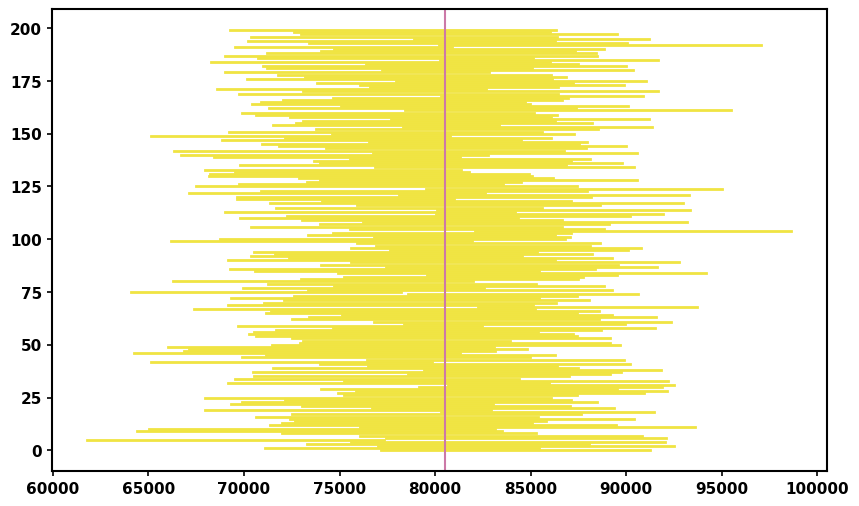

In [10]:
plt.figure(figsize=(10, 6))
for i, ci in enumerate(many_cis):
    plt.plot([ci[0], ci[1]], [i, i], color=gold, linewidth=2)
plt.axvline(x=population_median, color=pink);

### Which confidence intervals don't contain the true parameter?

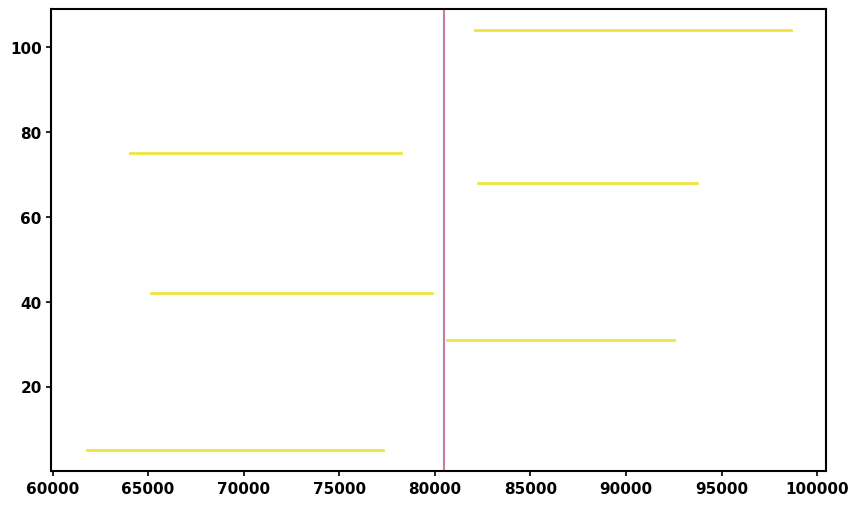

In [11]:
plt.figure(figsize=(10, 6))
count_outside = 0
for i, ci in enumerate(many_cis):
    if ci[0] > population_median or ci[1] < population_median:
        plt.plot([ci[0], ci[1]], [i, i], color=gold, linewidth=2)
        count_outside = count_outside + 1
plt.axvline(x=population_median, color=pink);

In [12]:
count_outside

6

- 6 of our 200 confidence intervals didn't contain the true parameter.
- That means 194/200, or 97% of them, did.
    - This is pretty close to 95%!

- In reality, you will have **only one confidence interval, and no way of knowing if it contains the true parameter**, since you have no way of knowing if your one original sample is good.

### Confidence tradeoffs

- When we use an "unlucky" sample to make our CI, the CI won't contain the population parameter.

- If we choose a 99% confidence level, 
    - only about 1% of our samples will be "unlucky", but
    - our intervals will be very wide and thus not that useful.

- If we choose an 80% confidence level, 
    - more of our samples will be "unlucky", but
    - our intervals will be narrower and thus more precise.

- At a fixed confidence level, how do we decrease the width of a confidence interval?
    - By taking a bigger sample!
    - We'll soon see how sample sizes, confidence levels, and CI widths are related to one another.

### Misinterpreting confidence intervals

Confidence intervals can be hard to interpret.

In [13]:
# Our interval:
[left, right]

[np.float64(70671.5), np.float64(86405.0)]

**Does this interval contain 95% of all salaries? No!** ❌

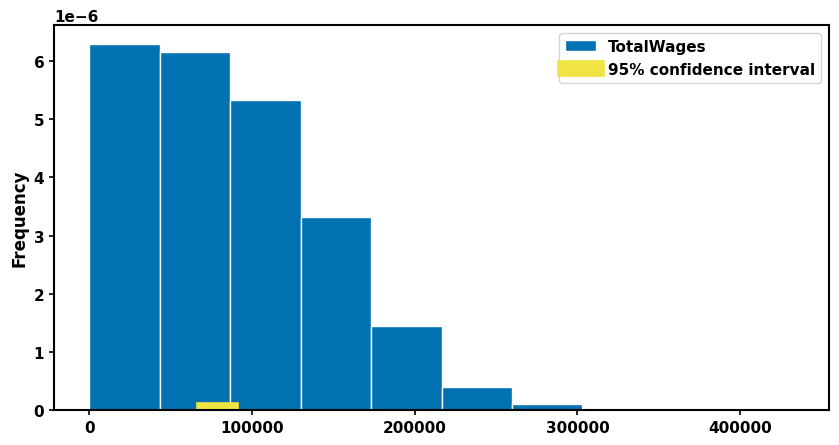

In [14]:
population.plot(kind='hist', y='TotalWages', density=True, ec='w', figsize=(10, 5))
plt.plot([left, right], [0, 0], color=gold, linewidth=12, label='95% confidence interval');
plt.legend();

However, this interval does contain 95% of all bootstrapped median salaries.

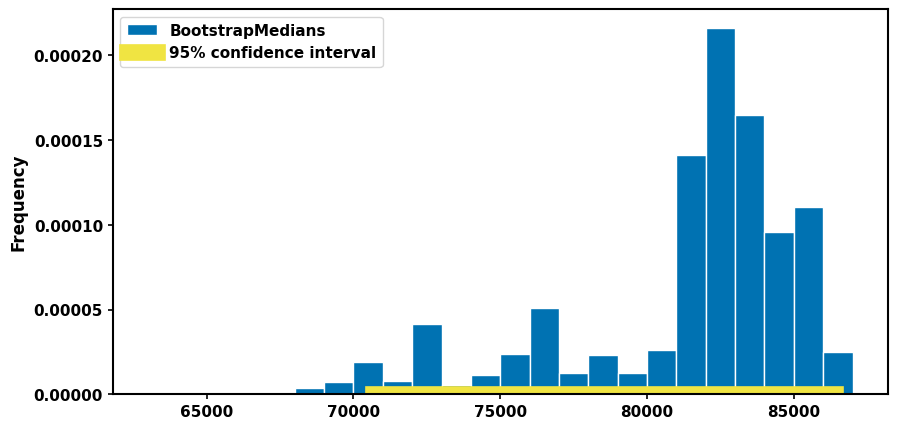

In [15]:
bpd.DataFrame().assign(BootstrapMedians=boot_medians).plot(kind='hist', density=True, bins=np.arange(63000, 88000, 1000), ec='w', figsize=(10, 5))
plt.plot([left, right], [0, 0], color=gold, linewidth=12, label='95% confidence interval');
plt.legend();

In [16]:
# Our interval:
[left, right]

[np.float64(70671.5), np.float64(86405.0)]

**Is there is a 95% chance that this interval contains the population parameter? No!** ❌

Why not?
- The population parameter is fixed. In reality, we might not know it, but it is **not random**.
- The interval above is not random, either (but the process that creates it is).
- For a given interval, the population parameter is in the interval, or it is not. There is no randomness involved.
- Remember that the 95% confidence is in the process that created an interval.
- This process – sampling, then bootstrapping, then creating an interval – creates a good interval roughly 95% of the time.

## Pitfalls of bootstrapping

### Bootstrapping rules of thumb

- Bootstrapping is powerful! We only had to collect a single sample from the population to get the (approximate) distribution of the sample median.

- But it has limitations:
    - It is not good for sensitive statistics, like the max or min.
         - A sensitive statistic is one that might change a lot for a different sample.
    - It only gives useful results if the sample is a good approximation of population.
        - If our original sample was not representative of the population, the resulting bootstrapped samples will also not be representative of the population.

### Example: Estimating the max of a population

- Suppose we want to estimate the maximum salary of all San Diego city employees, given just a single sample, `my_sample`.
- Our estimate will be the max in the sample. This is a statistic.
- To get the empirical distribution of this statistic, we bootstrap:

In [17]:
n_resamples = 5000
boot_maxes = np.array([])

for i in range(n_resamples):
    resample = my_sample.sample(500, replace=True)
    boot_max = resample.get('TotalWages').max()
    boot_maxes = np.append(boot_maxes, boot_max)

In [18]:
boot_maxes

array([299902., 299902., 299902., ..., 299902., 299902., 256566.],
      shape=(5000,))

### Visualize

Since we have access to the population, we can find the population maximum directly, without bootstrapping.

In [19]:
population_max = population.get('TotalWages').max()
population_max

np.int64(433011)

Does the population maximum lie within the bulk of the bootstrapped distribution?

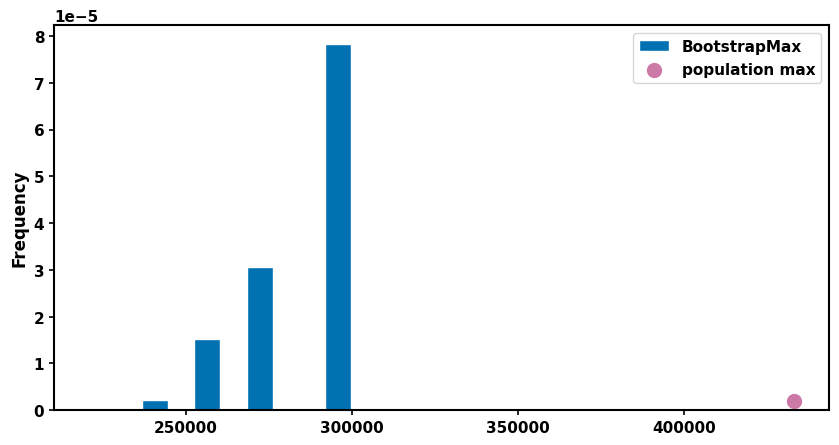

In [20]:
bpd.DataFrame().assign(BootstrapMax=boot_maxes).plot(kind='hist', 
                                                     density=True, 
                                                     bins=10,
                                                     ec='w',
                                                     figsize=(10, 5))
plt.scatter(population_max, 0.000002, color=pink, s=100, label='population max')
plt.legend();

No, the bootstrapped distribution doesn't capture the population maximum (<b>pink dot</b>) of \$433,011. Why not? 🤔

In [21]:
my_sample.get('TotalWages').max()

np.int64(299902)

- The largest value in our original sample was \\$299,902. So, the largest value in any bootstrapped sample is at most \\$299,902.

- Generally, bootstrapping works better for measures of central tendency or variation (mean, median, standard deviation) than it does for extreme values (max and min).

## Center and spread

### Some questions

- If we know the mean and standard deviation of a distribution, but nothing else, what can we say about its shape?

- What is the "normal" distribution, and how does it relate to some of the distributions we've already seen?

- We're going to start to address these questions over the next few lectures.

- But first, we need to discuss ways of measuring the center and spread of a numerical distribution.

### Central tendency

- A measure of **central tendency** describes where a numerical distribution is centered.

- We've already seen the **mean** and **median** as two ways to measure central tendency.

### Concept Check ✅ 

<center>
    <table><tr>
        <td> <center><img src="images/hist.jpg" width=70%></center>  </td>
        <td> <center><img src="images/hist2.jpg" width=70%></center> </td>
    </tr></table>
</center>

Are the means of these two distributions the same or different? What about their medians?

- A. Both are the same
- B. Means are different, medians are same
- C. Means are same, medians are different
- D. Both are different

### Example: Flight delays ✈️

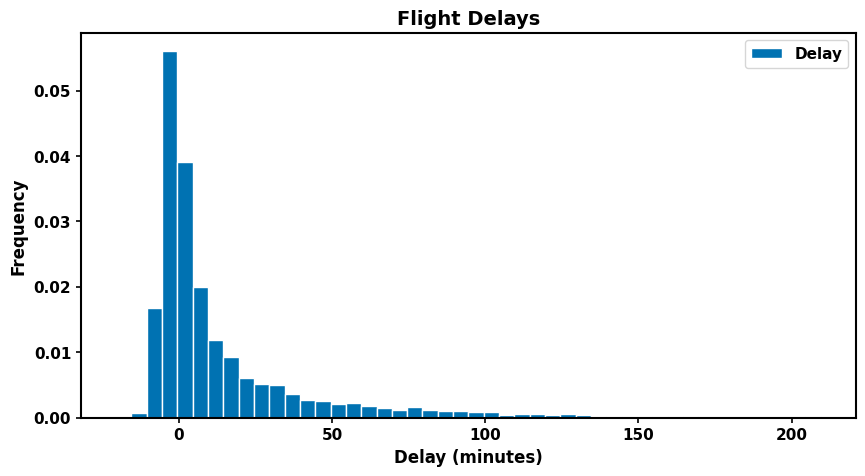

In [22]:
delays = bpd.read_csv('data/united_summer2015.csv')
delays.plot(kind='hist', y='Delay', bins=np.arange(-20.5, 210, 5), density=True, ec='w', figsize=(10, 5))
plt.title('Flight Delays')
plt.xlabel('Delay (minutes)');

**Question**: Which is larger – the mean or the median?

In [23]:
delays.get('Delay').mean()

np.float64(16.658155515370705)

In [24]:
delays.get('Delay').median()

np.float64(2.0)

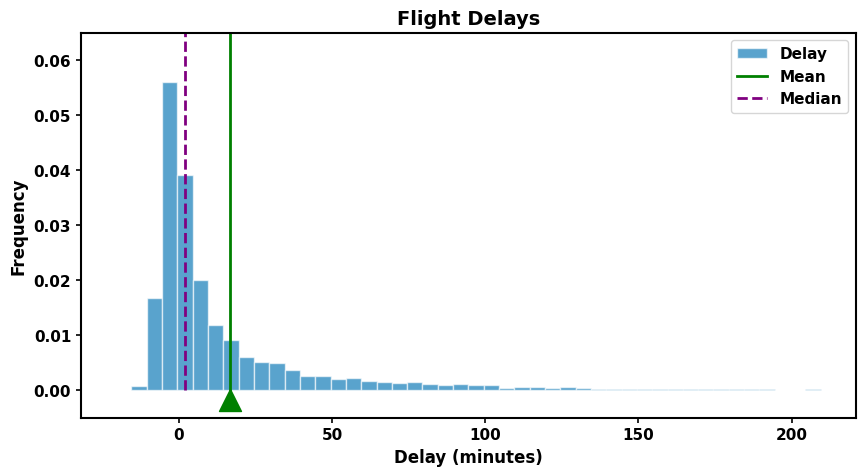

In [25]:
delays.plot(kind='hist', y='Delay', bins=np.arange(-20.5, 210, 5), density=True, ec='w', alpha=0.65, figsize=(10, 5))
plt.plot([delays.get('Delay').mean(), delays.get('Delay').mean()], [0, 1], color='green', label='Mean', linewidth=2)
plt.scatter([delays.get('Delay').mean()], [-0.0017], color='green', marker='^', s=250)
plt.plot([delays.get('Delay').median(), delays.get('Delay').median()], [0, 1], color='purple', label='Median', linewidth=2, linestyle='dashed')
plt.title('Flight Delays')
plt.xlabel('Delay (minutes)')
plt.ylim(-0.005, 0.065)
plt.legend();

### Comparing the mean and median

- **Mean**: Balance point of the histogram.
    - Numerically: the sum of the differences between all data points and the mean is 0.
    - Physically: Think of a see-saw.

- **Median**: Half-way point of the data.
    - Half of the area of a histogram is to the left of the median, and half is to the right.


- If the distribution is symmetric around a value, then that value is both the mean and the median.

- If the distribution is **skewed**, then the mean is pulled away from the median in the direction of the tail.

- **Key property**: The median is more **robust** (less **sensitive**) to **outliers**.

## Standard deviation

### Question: How "wide" is a distribution? 

- **One idea**: “biggest value - smallest value” (known as the **range**).
    - Issue: this doesn’t tell us much about the shape of the distribution.

- **Another idea**: "standard deviation".
    - The mean is at the center. 
    - The standard deviation quantifies how far the data points typically are from the center.

### Deviations from the mean

In [26]:
data = np.array([2, 3, 3, 9])
np.mean(data)

np.float64(4.25)

In [27]:
deviations = data - np.mean(data)
deviations

array([-2.25, -1.25, -1.25,  4.75])

Each entry in `deviations` describes how far the corresponding element in `data` is from 4.25.

What is the average deviation?

In [28]:
np.mean(deviations)

np.float64(0.0)

- This is true of any dataset – the average deviation from the mean is always 0.
- This implies that the average deviation itself is not useful in measuring the spread of data.

### Average **squared** deviation

In [29]:
# Square all the deviations:
deviations ** 2

array([ 5.06,  1.56,  1.56, 22.56])

In [30]:
variance = np.mean(deviations ** 2)
variance

np.float64(7.6875)

This quantity, the average squared deviation from the mean, is called the **variance**.

### Standard deviation

- Our data usually has units, e.g. dollars.
- The variance is in "squared" units, e.g. $\text{dollars}^2$.
- To account for this, we can take the square root of the variance, and the result is called the **standard deviation**.

In [31]:
# Standard deviation (SD) is the square root of the variance.
sd = variance ** 0.5
sd

np.float64(2.7726341266023544)

### Standard deviation

- The standard deviation (SD) measures something about how far the data values are from their average.
    - It is not directly interpretable because of the squaring and square rooting.
    - But generally, **larger SD = more spread out**.

- The standard deviation has the same units as the original data.

- `numpy` has a function, `np.std`, that calculates the standard deviation for us.

In [32]:
# Note that this evaluates to the same number we found on the previous slide.
np.std(data)

np.float64(2.7726341266023544)

### Variance and standard deviation

To summarize:

$$\begin{align*}\text{variance} &= \text{average squared deviation from the mean}\\
&= \frac{(\text{value}_1 - \text{mean})^2 + ... + (\text{value}_n - \text{mean})^2}{n}\\
\text{standard deviation} &= \sqrt{\text{variance}}
\end{align*}$$

where $n$ is the number of observations.

### What can we do with the standard deviation?

It turns out, in **any** numerical distribution, the bulk of the data are in the range “mean ± a few SDs”.

In the next class, we'll make this more precise.

## Summary, next time

### Summary: Bootstrapping and confidence intervals

- Bootstrapping gives us a way to generate the empirical distribution of a sample statistic. From this distribution, we can create a $c$% confidence interval by taking the middle $c$% of values of the bootstrapped distribution.
- Such an interval allows us to quantify the uncertainty in our estimate of a population parameter.
    - Instead of providing just a single estimate of a population parameter, we can provide a range of estimates.
- **Confidence intervals need to be interpreted with care.** The confidence is in our process of generating intervals, not in any one particular interval.
- Bootstrapping works well for statistics that don't vary too much from one sample to another (like mean and median). It does not work work well for sensitive statistics that can vary a lot across samples (like min and max).

### Summary: Center and spread

- Mean and median are measures of central tendency.
- Variance and standard deviation (SD) quantify how spread out data points are.
    - Standard deviation is the square root of variance.
    - Roughly speaking, the standard deviation describes how far values in a dataset typically are from the mean.
    - Most data falls within a few SDs of the mean.

### Next time

What is the "normal" distribution, and how does it relate to some of the distributions we've already seen?